# Lesson 1.8 - Linear Algebra Basics

In [1]:
import numpy as np

## Vector operations

Basically they are just element-wise operations

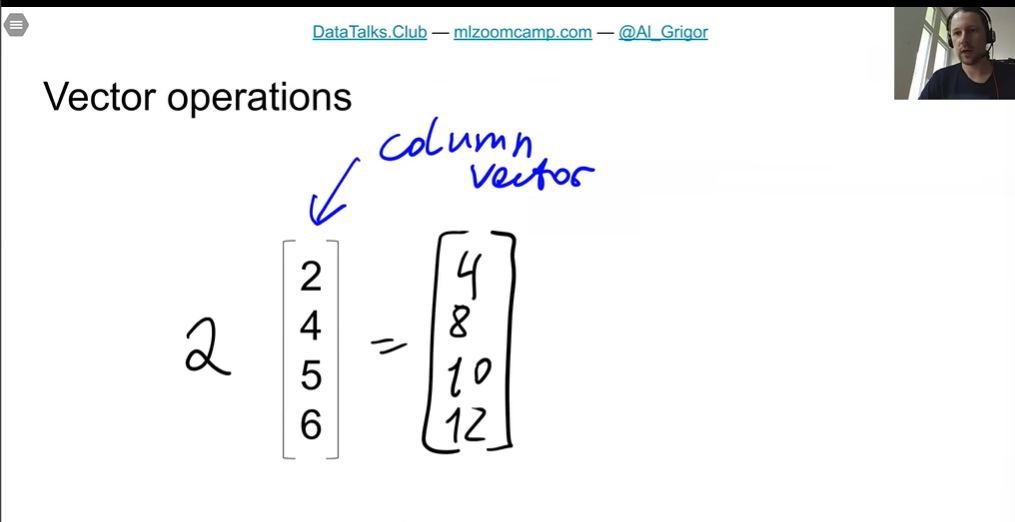

In [2]:
a = np.array([2, 4, 5, 6])
a

array([2, 4, 5, 6])

In [3]:
a * 2

array([ 4,  8, 10, 12])

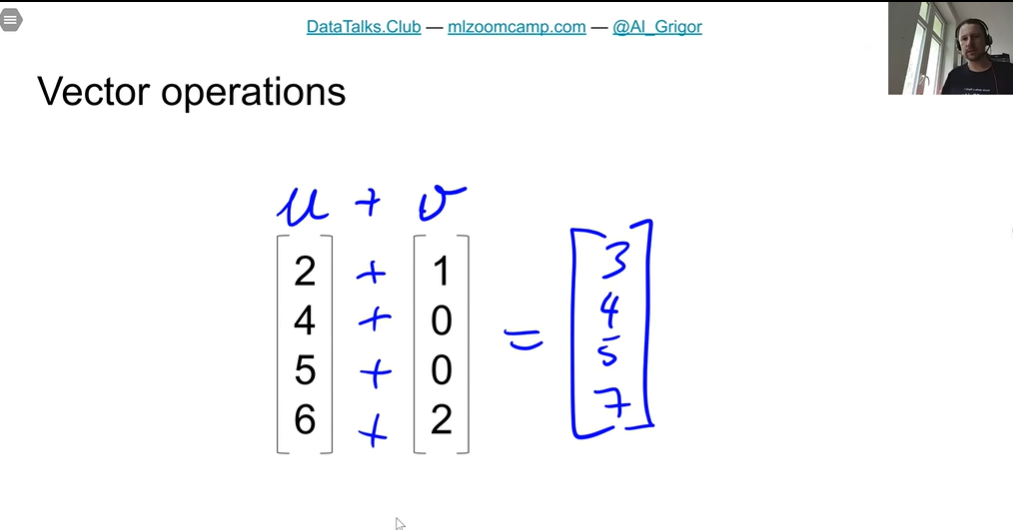

**Last row: `6 + 2`, should be `8`**

In [4]:
u = np.array([2, 4, 5, 6])
v = np.array([1, 0, 0, 2])

u + v

array([3, 4, 5, 8])

In [5]:
u * v

array([ 2,  0,  0, 12])

## Vector-vector multiplication

**IMPORTANT:** The dot product is not the same as element-wise multiplication. Element-wise multiplication is just the first step.

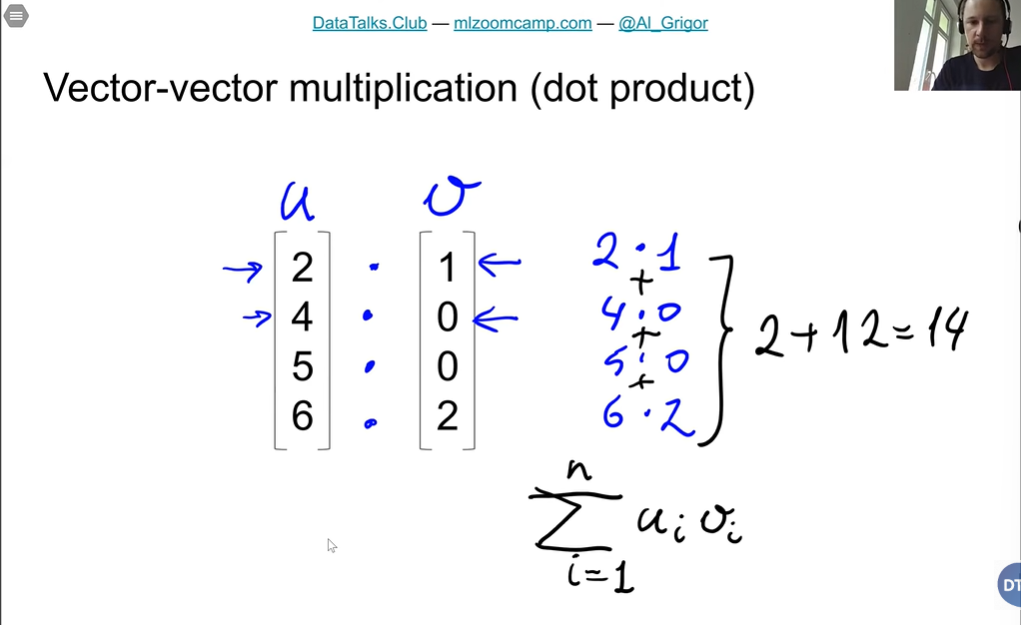

In [6]:
# Both vectors need to have the same shape
print(u.shape[0])
print(v.shape[0])

4
4


In [7]:
# Manual implementation of dot product
def vector_to_vector_multiplication(u, v):
    assert u.shape[0] == v.shape[0], "Vectors must have the same shape"

    n = u.shape[0]

    result = 0.0

    for i in range(n):
        result += u[i] * v[i]

    return result


vector_to_vector_multiplication(u, v)


np.float64(14.0)

In [8]:
# There is a built-in function in numpy to calculate the dot product
np.dot(u, v)

np.int64(14)

## Matrix-vector multiplication

Matrix-vector multiplication is just vector-vector multiplication (the dot product) repeated once for every row of the matrix

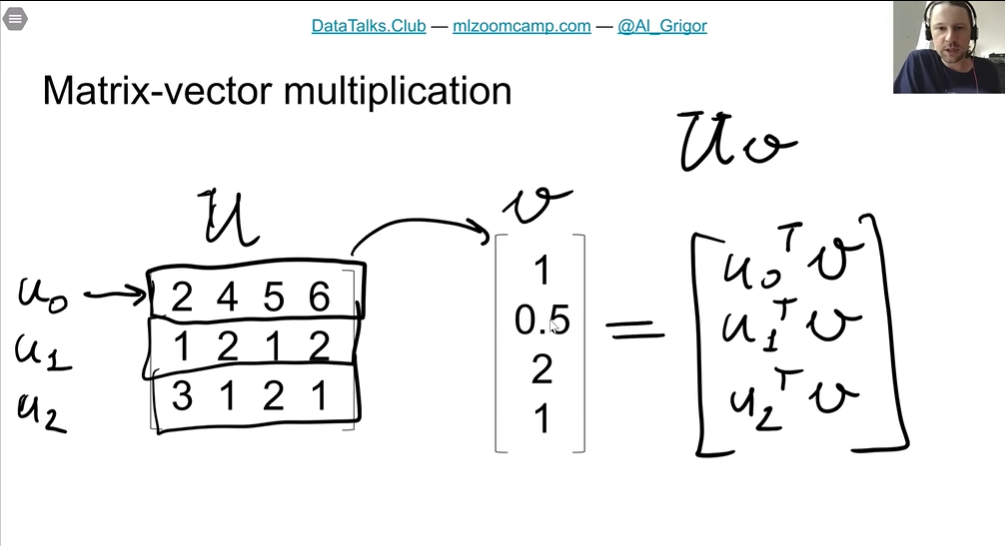

Each row-vector and column-vector pairing must be the same shape (e.g., if v has 4 elements, each matrix row should have 4 elements as well)

In [9]:
U = np.array([
    [2, 4, 5, 6],
    [1, 2, 1, 2],
    [3, 1, 2, 1]
])

v = np.array([1, 0.5, 2, 1])

print(U.shape)
print(v.shape)

(3, 4)
(4,)


In [10]:
# Manual implementation of matrix-vector multiplication
def matrix_to_vector_multiplication(U, v):

    # U.shape[1] is the number of columns in U
    # v.shape[0] is the number of rows in v
    # They must be equal for the multiplication to be valid
    assert U.shape[1] == v.shape[0], "Matrix columns must match vector rows"

    # The resulting vector should have the same number of elements as there are rows in matrix U
    num_rows = U.shape[0]
    result = np.zeros(num_rows)

    # For each row in matrix U, we calculate the dot product with vector v
    # Then we store the result in the corresponding position in the result vector
    for i in range(num_rows):
        result[i] = vector_to_vector_multiplication(U[i], v)

    return result


matrix_to_vector_multiplication(U, v)

array([20. ,  6. ,  8.5])

In [11]:
# We use the same .dot() function to calculate the matrix-vector multiplication
np.dot(U, v)

array([20. ,  6. ,  8.5])

## Matrix-matrix multiplication

Basically, we are just doing matrix-vector operations for each column vector in V (e.g., each column in V will compute the dot product with matrix U)

**TIP:** Understand the basics. Once you know how to do vector operations, all the advanced operations discussed here actually just build up on it. 

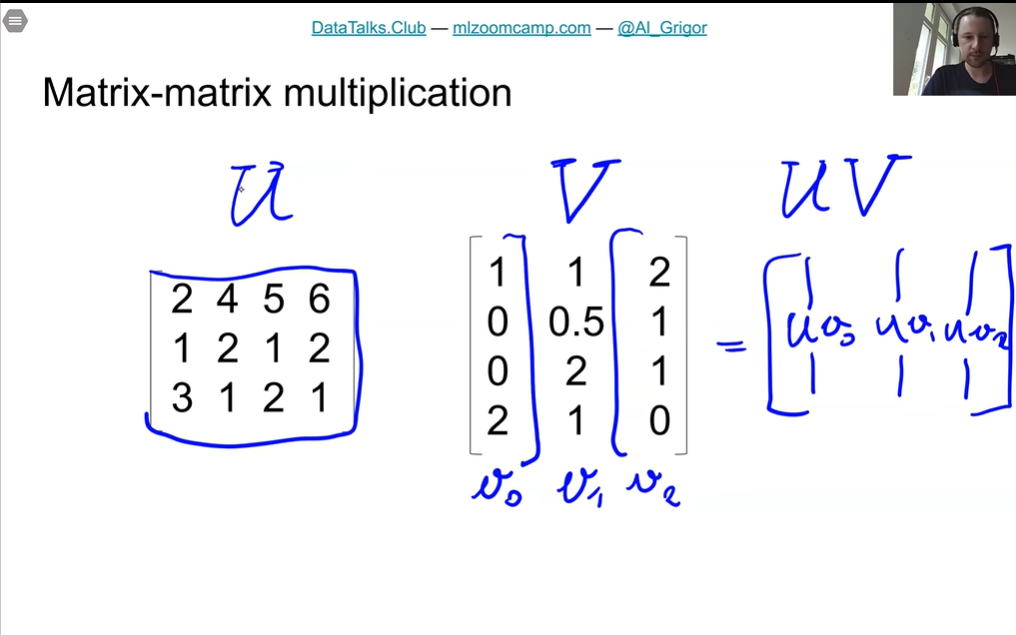

In [12]:
U = np.array([
    [2, 4, 5, 6],
    [1, 2, 1, 2],
    [3, 1, 2, 1]
])

V = np.array([
    [1, 1, 2],
    [0, 0.5, 1],
    [0, 2, 1],
    [2, 1, 0]
])

print(U.shape)
print(V.shape)

(3, 4)
(4, 3)


In [13]:
def matrix_to_matrix_multiplication(U, V):

    # U.shape[1] is the number of columns in U (inner dimension of the first matrix)
    # V.shape[0] is the number of rows in V (inner dimension of the second matrix)
    # They must be equal for the multiplication to be valid
    assert U.shape[1] == V.shape[0], "Matrix A columns must match Matrix B rows"

    # Number of rows comes from U (outer dimension of the first matrix)
    num_rows = U.shape[0]

    # Number of columns comes from V (outer dimension of the second matrix)
    num_cols = V.shape[1]

    # The resulting matrix will have the same number of rows as U and the same number of columns as V (outer dimensions)
    result = np.zeros((num_rows, num_cols))

    # Loop through each column vector in V
    for i in range(num_cols):
        vi = V[:, i]  # Current column vector
        Uvi = matrix_to_vector_multiplication(U, vi)  # Get dot product for the current column vector and the matrix
        result[:, i] = Uvi  # Reassign entire column with result from above

    return result


matrix_to_matrix_multiplication(U, V)

array([[14. , 20. , 13. ],
       [ 5. ,  6. ,  5. ],
       [ 5. ,  8.5,  9. ]])

In [14]:
# Again, we use .dot() - can handle vector-vector, matrix-vector, matrix-matrix multiplication
np.dot(U, V)

array([[14. , 20. , 13. ],
       [ 5. ,  6. ,  5. ],
       [ 5. ,  8.5,  9. ]])

## Identity matrix

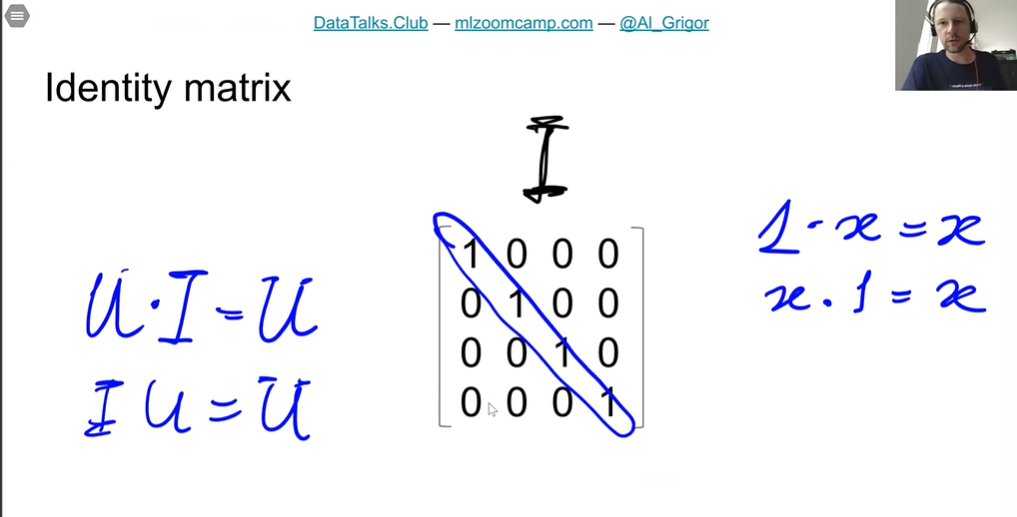

In [15]:
np.eye(4)

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

In [16]:
# Important concept:
# When we multiply a matrix by the identity matrix, we get that matrix back
V = np.array([
    [1, 1, 2],
    [0, 0.5, 1],
    [0, 2, 1],
    [2, 1, 0]
])

print(V)
print(V.shape)

[[1.  1.  2. ]
 [0.  0.5 1. ]
 [0.  2.  1. ]
 [2.  1.  0. ]]
(4, 3)


In [17]:
I = np.eye(3)

print(I)
print(I.shape)

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
(3, 3)


In [18]:
np.dot(V, I)

array([[1. , 1. , 2. ],
       [0. , 0.5, 1. ],
       [0. , 2. , 1. ],
       [2. , 1. , 0. ]])

## Matrix inverse

The inverse of a matrix is the matrix that "undoes" it — multiply them together and you get back to the identity matrix, the same way a number times its reciprocal gives you 1.

*Only square matrixes have inverses*

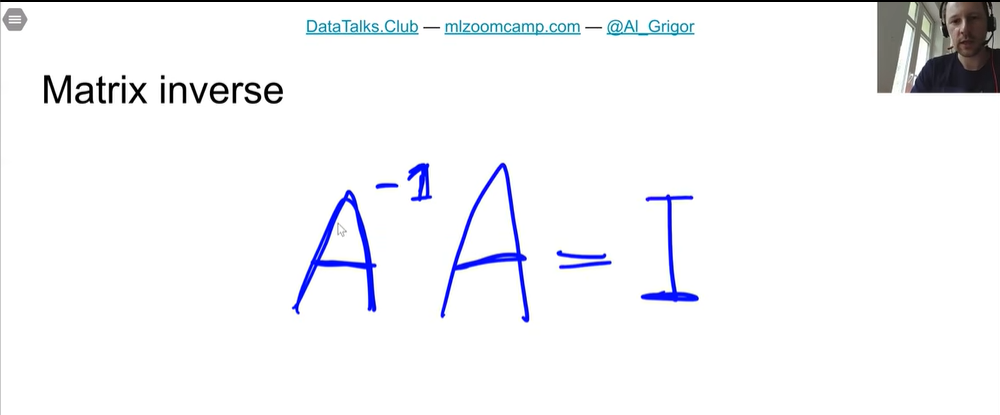

In [19]:
V = V = np.array([
    [1, 1, 2],
    [0, 0.5, 1],
    [0, 2, 1]
])

print(V)
print(V.shape)

[[1.  1.  2. ]
 [0.  0.5 1. ]
 [0.  2.  1. ]]
(3, 3)


In [20]:
# Get the inverse of a matrix
V_inv = np.linalg.inv(V)

print(V_inv)
print(V_inv.shape)

[[ 1.         -2.          0.        ]
 [ 0.         -0.66666667  0.66666667]
 [ 0.          1.33333333 -0.33333333]]
(3, 3)


In [21]:
# When we multiply a matrix by its inverse, we get the identity
np.dot(V, V_inv)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])